# Gene Expression Peak-Trough analysis using Polar Plots

April 8, 2024

Analyze the chromatin at genes during peak and trough gene expression.

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from src.mnase_replication_timing_analysis import MNaseOriginAnalysis

# Compute replication profile for each gene

For each gene
1. Compute the raw replication profile
2. Compute its replication time (early/late)
3. Will need to normalize by the replicate's S phase
4. Compute the correlation with its gene expression


In [3]:
mnase_analysis = MNaseOriginAnalysis()

In [4]:
replicate = 1
chromosome = 10
mnase_analysis.load_mnase_data(replicate, chromosome)

In [5]:
mnase_analysis.compute_sliding_window_counts_all_times()
mnase_analysis.normalize_samples()

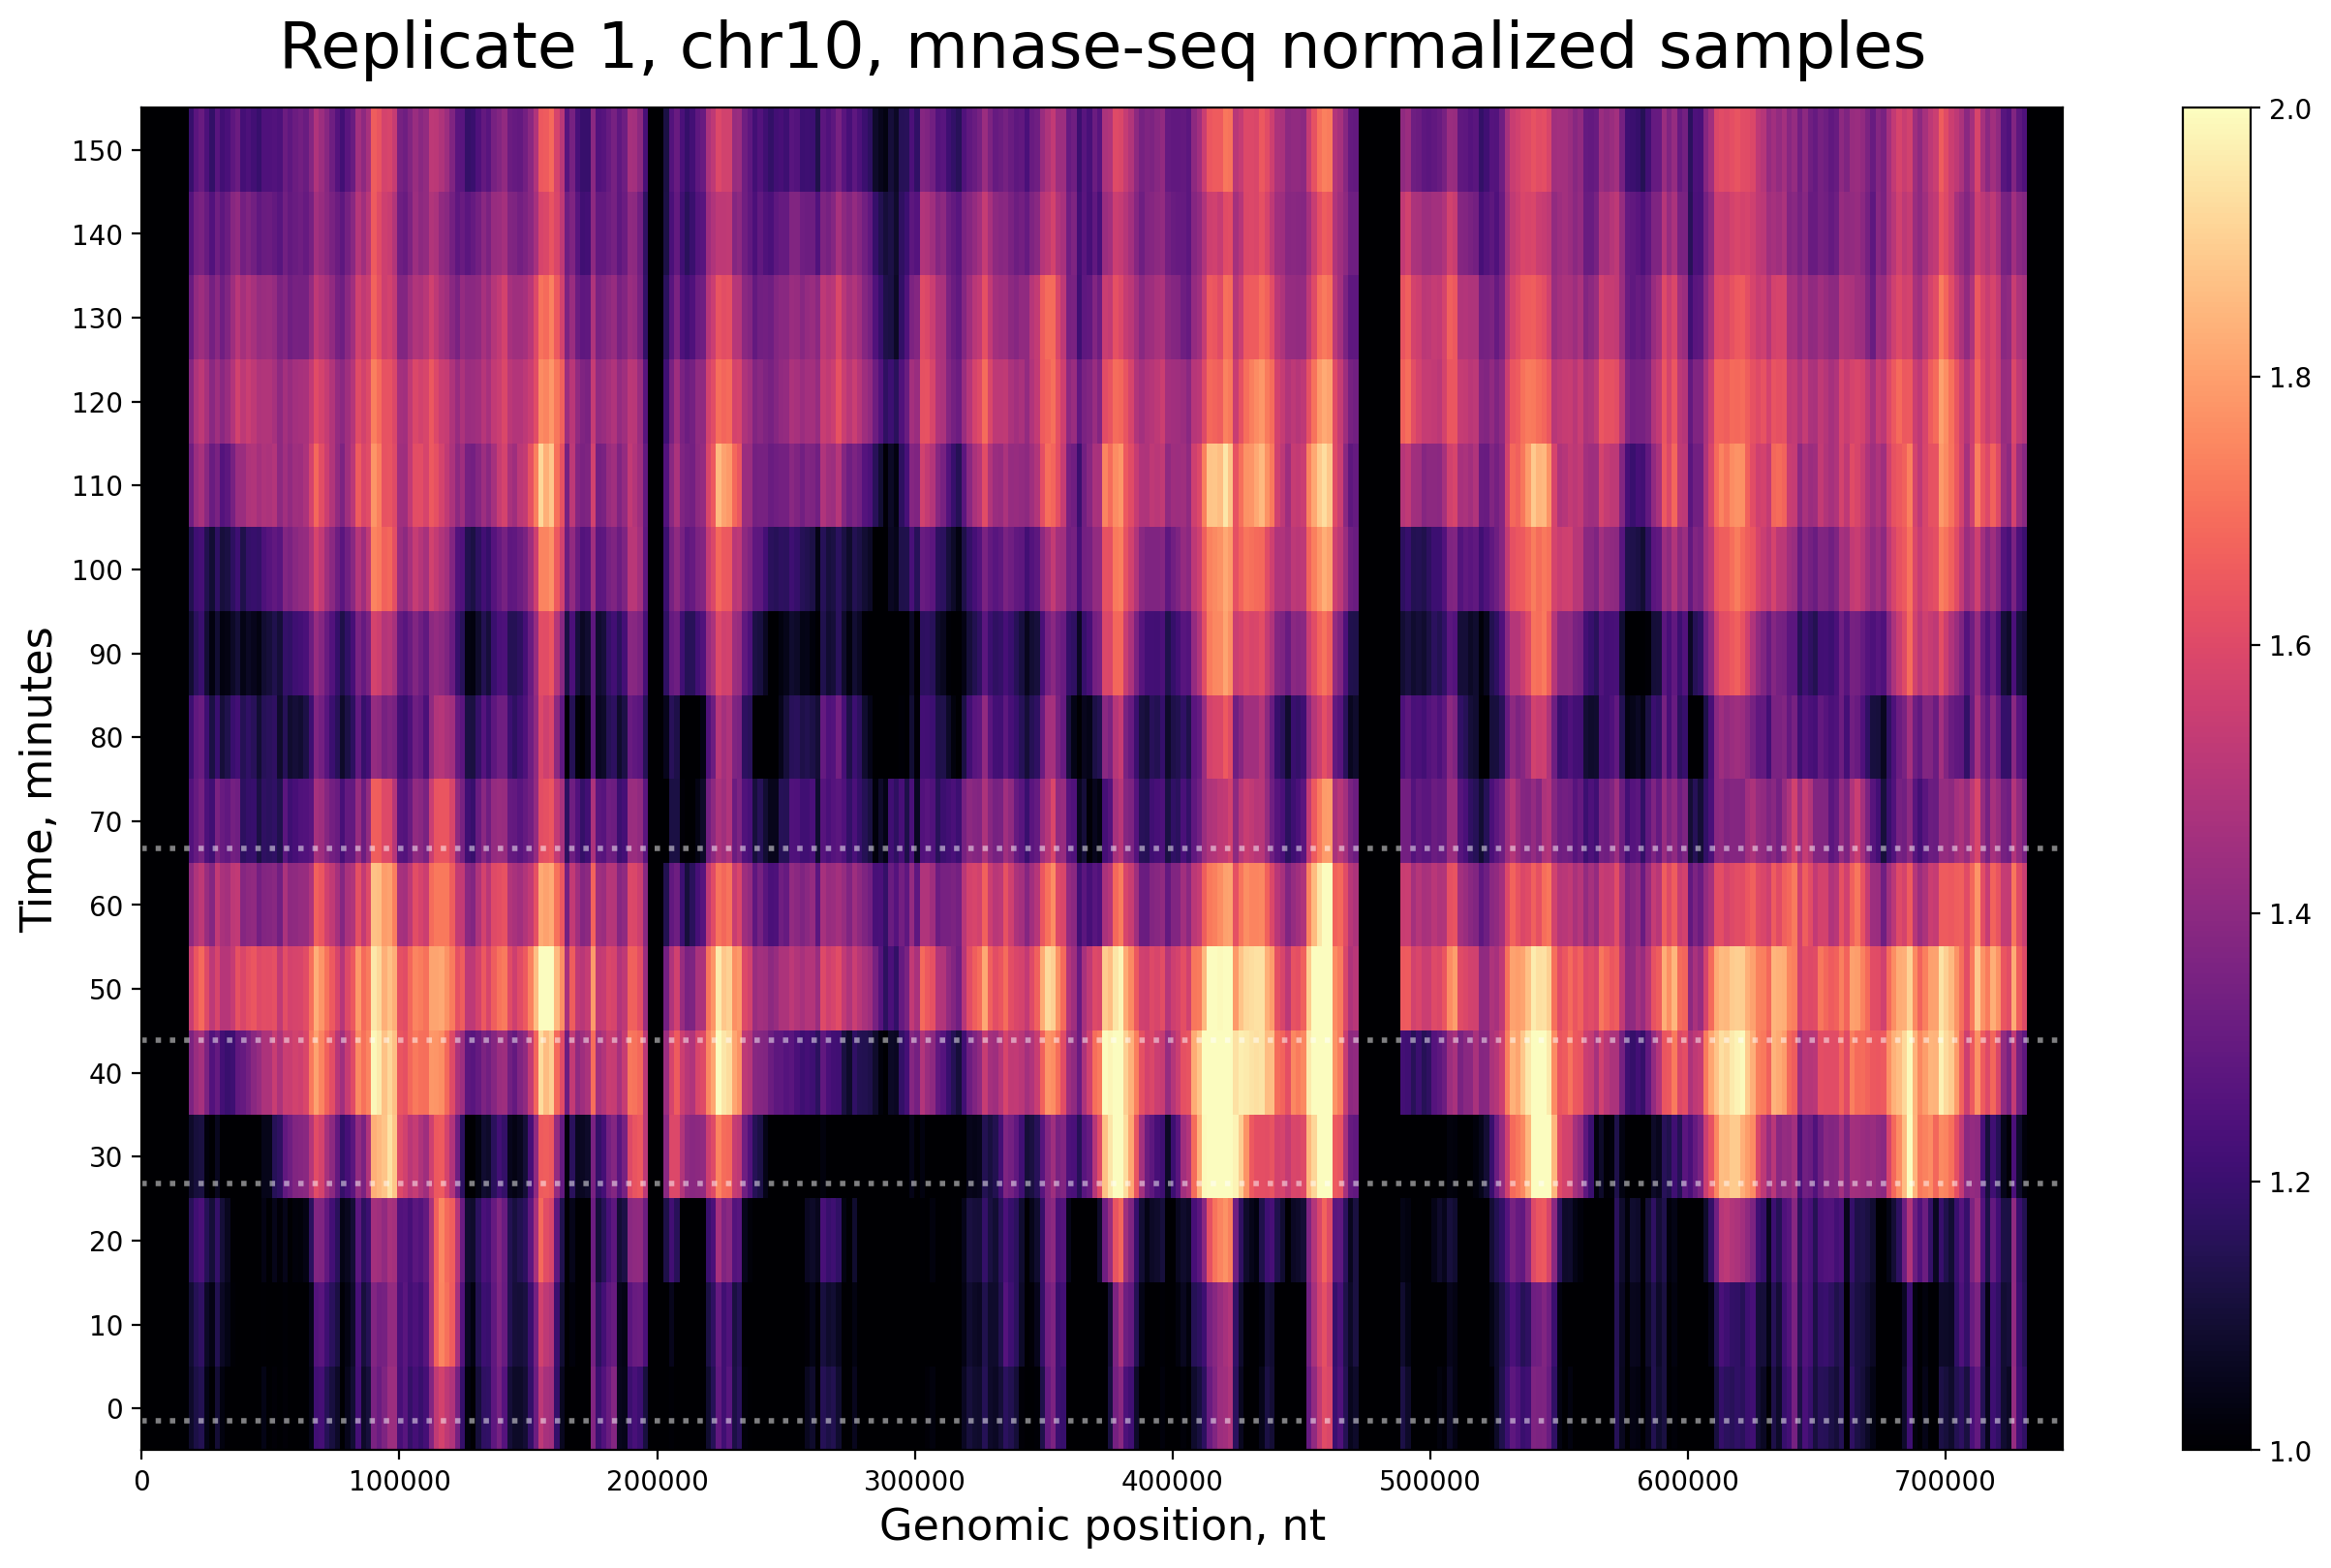

In [6]:
mnase_analysis.plot_heatmap(plot_norm_by_copy=True)

In [8]:
mnase_analysis.compute_sliding_window_counts_all_times()
mnase_analysis.normalize_samples()

In [12]:
mnase_analysis.compute_bin_curves_and_expression_correlations(1)

1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 

In [31]:
from src.sgd import get_orfname
from src.config import load_yl_rg1_vst_config

config = load_yl_rg1_vst_config(1)
intervals = config.intervals_wt1[0]
mu0, lambda_val, delta, gamma1, gamma2, alpha = intervals[0], intervals[1],\
    intervals[2], intervals[7], intervals[8], intervals[5]


In [84]:
# Compute the bin curves for all genes, we can use this as a start for determining
# early and lateness of origin of replication gene.
#
# The bin curve will help us determine when the origin is fired, let's plot a few and
# determine if there is a good way to dilineate early vs late...
#

# Plot a few of the bin curves at random

# Assume there is a threshold
# at 60 minutes (load replicate's timing profile), G2 is the end
# G1 is the beginning, when does the bin curve reach some percentage of G2's occupancy?
# 
from src.TracerPlotter import normalize_max_min

def normalize_first_cc_bin_curves(dat, lambda_val):
    """Normalize the data such that within the first cell cycle"""
    x = dat.index
    first_cc_indices = x < lambda_val
    normalized_dat = normalize_max_min(dat, first_cc_indices)
    return normalized_dat
    
def add_gene_bin_curve(gene_name, normalized_bin_curves, repl_timing_df):
    orf_name = get_orfname(gene_name)
    x = normalized_bin_curves.columns    
    y = normalized_bin_curves.loc[orf_name]
    
    # when does the normalized bin curve exceed the threshold?
    cross_point_time = repl_timing_df.loc[orf_name]
    
    plt.scatter(cross_point_time, y[cross_point_time], marker='D')
    plt.plot(x, y, label=f"{gene_name}, {cross_point_time}")

normalized_bin_curves = mnase_analysis.bin_curves.apply(lambda row: 
    normalize_first_cc_bin_curves(row, lambda_val), axis=1)


In [106]:
# When does the normalized bin curve reach 20%, take the max
# the first (true) value of exceeding the threshold, the column (time)
# of this occurrence is the bin's replication timing
threshold = 0.75
repl_timing_df = (normalized_bin_curves.dropna() > threshold).idxmax(axis=1)

Text(0, 0.5, 'Normalized occupancy')

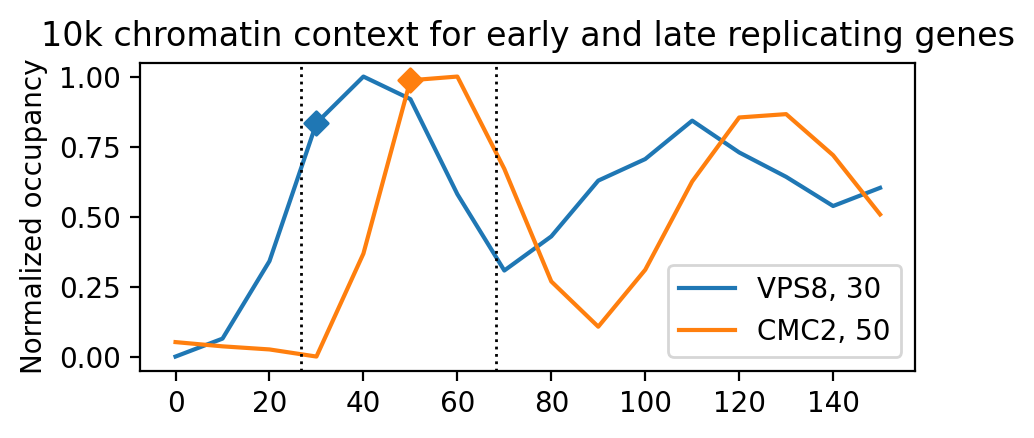

In [117]:
plt.figure(figsize=(5, 2))
add_gene_bin_curve('VPS8', normalized_bin_curves, repl_timing_df)
add_gene_bin_curve('CMC2', normalized_bin_curves, repl_timing_df)
plt.legend()

plt.axvline(lambda_val, lw=1, ls='dotted', c='black')
plt.axvline(mu0, lw=1, ls='dotted', c='black')
plt.title("10k chromatin context for early and late replicating genes")
plt.ylabel("Normalized occupancy")

In [ ]:
# What does the chromatin look like at various stages of the cell cycle for these two genes?
# can this help determine if we have estimated the location of S-phase properly in our model?
# i.e. is the alpha parameter properly tuned?
#
# Ideally, we could plot advancement from the start of S-phase to the end of S-phase
# and see how the chromatin doubles for VPS8 earlier than CMC2
# but we have done some normalization prior to the deconvolution, 
# so the signal may actually different than expected.
